# IceCube 2D GNN

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torch_geometric.nn import DynamicEdgeConv, global_mean_pool

import helper_icecube as ic
import helper_dl as dl

In [2]:
# If the kernel is not restarted, packages are not reloaded by default
# This is to make sure the changes in the python scripts are loaded
import importlib

importlib.reload(ic)
importlib.reload(dl);

### Loading data

In [3]:
DATA_PATH = "../datasets/icecube"

# Load the data
train_dataset, val_dataset, test_dataset = ic.load_icecube_data(DATA_PATH)

In [4]:
# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")

The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.


In [5]:
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")

The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']


In [6]:
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}


In [7]:
# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]


In [8]:
# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")

The first event of the training dataset has 12 hits, i.e., detected photons.


In [9]:
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")

Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x = -2.5, y = -2.5
Hit 2: time = 8.996675814194964, x = 2.5, y = -2.5
Hit 3: time = 12.021784213609394, x = 2.5, y = -2.5
Hit 4: time = 12.923289636173713, x = 2.5, y = -2.5
Hit 5: time = 25.1516276582378, x = -2.5, y = -0.8333333333333333
Hit 6: time = 15.286326473533162, x = 0.8333333333333335, y = -0.8333333333333333
Hit 7: time = 15.14788039212255, x = 2.5, y = -0.8333333333333333
Hit 8: time = 16.565114961505415, x = -0.8333333333333333, y = 0.8333333333333335
Hit 9: time = 19.47621700139486, x = -0.8333333333333333, y = 0.8333333333333335
Hit 10: time = 16.912010076540938, x = 2.5, y = 2.5
Hit 11: time = 19.57845737402364, x = 2.5, y = 2.5


In [10]:
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")

The first event of the training dataset has the following hit times: [14.5, 17.1, 9, 12, 12.9, 25.2, 15.3, 15.1, 16.6, 19.5, 16.9, 19.6]
The first event of the training dataset has the following hit x positions: [-2.5, -2.5, 2.5, 2.5, 2.5, -2.5, 0.833, 2.5, -0.833, -0.833, 2.5, 2.5]
The first event of the training dataset has the following hit y positions: [-2.5, -2.5, -2.5, -2.5, -2.5, -0.833, ..., -0.833, 0.833, 0.833, 2.5, 2.5]


### Hyperparameter selection

In [11]:
# Hyperparameters
learning_rate = 5e-4
batch_size = 32
num_epochs = 100
patience = 10 # Training loop with early stopping, if the validation loss does not improve for 'patience' epochs

### Plot saving

In [12]:
PLOT_PATH = "/mnt/Datos/LaTeX/deep-learning/ex4/figures"
if not os.path.exists(PLOT_PATH):
    raise Exception("Plots folder does not exist")

# Choose whether to save the plots or not
SAVE_PLOTS = True

if SAVE_PLOTS:
    LOSS_PATH = f'{PLOT_PATH}/loss-curves.png'
else:
    LOSS_PATH = None

### Prepare data por training

In [13]:
# Normalize the labels
ic.normalize_data(train_dataset)

# Create the dataloaders
train_loader, val_loader, test_loader = ic.create_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=batch_size)

In [14]:
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")

The first event of the training dataset has the following hit times: [0.158, 0.235, 0, 0.0872, 0.113, 0.466, ..., 0.177, 0.218, 0.302, 0.228, 0.305]
The first event of the training dataset has the following hit x positions: [-1.41, -1.41, 1.3, 1.3, 1.3, -1.41, 0.395, 1.3, -0.507, -0.507, 1.3, 1.3]
The first event of the training dataset has the following hit y positions: [-1.35, -1.35, -1.35, -1.35, -1.35, ..., -0.451, 0.448, 0.448, 1.35, 1.35]


### Definition of the model and the loss function

In [ ]:
class MLP(nn.Module):
    # define the MLP

SyntaxError: incomplete input (2303996279.py, line 2)

In [ ]:
# Defintion of the GNN model
# Use the DynamicEdgeConv layer from the pytorch geometric package like this:
# MLP is a Multi-Layer Perceptron that is used to compute the edge features, you still need to define it.
# The input dimension to the MLP should be twice the number of features in the input data (i.e., 2 * n_features),
# because the edge features are computed from the concatenation of the two nodes that are connected by the edge.
# The output dimension of the MLP is the new feauture dimension of this graph layer.
class GNNEncoder(nn.Module):
    def __init__(self, ...):
        super(GNNEncoder, self).__init__()
        
        layer = DynamicEdgeConv(
                    MLP(...),
                    aggr='mean', k=k,  # k is the number of nearest neighbors to consider
                )

    def forward(self, data):
        # data is a batch graph item. it contains a list of tensors (x) and how the batch is structured along this list (batch)
        x = data.x
        batch = data.batch

        # loop over the DynamicEdgeConv layers:
        for layer in self.layer_list:
            x = layer(x, batch)

        # the output of the last layer has dimensions (n_batch, n_nodes, graph_feature_dimension)
        # where n_batch is the number of graphs in the batch and n_nodes is the number of nodes in the graph
        # i.e. one output per node (i.e. the hits in the event).
        # To combine all node feauters into single prediction, we recommend to use global pooling
        x = global_mean_pool(x, batch) # -> (n_batch, output_dim)
        # x is now a tensor of shape (n_batch, output_dim)

        # either your the last graph feature dimension is already the output dimension you want to predict
        # or you need to add a final MLP layer to map the output dimension to the number of labels you want to predict
        x = self.final_mlp(x)

        return x

### Training the neural network

In [ ]:
# Choose the best device
device = dl.get_device()
print(f"Using device: {device}")

# Initialize the model
model = GNNEncoder.to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Print the model summary before moving it to the device
summary(model);

Using device: xpu
Layer (type:depth-idx)                   Param #
├─pdf: 1-1                               --
|    └─ModuleList: 2-1                   --
|    |    └─ModuleList: 3-1              --
|    └─ModuleList: 2-2                   --
├─GalahCNN: 1-2                          --
|    └─Sequential: 2-3                   --
|    |    └─Conv1d: 3-2                  128
|    |    └─ReLU: 3-3                    --
|    |    └─MaxPool1d: 3-4               --
|    |    └─Conv1d: 3-5                  2,592
|    |    └─ReLU: 3-6                    --
|    |    └─MaxPool1d: 3-7               --
|    |    └─Conv1d: 3-8                  6,208
|    |    └─ReLU: 3-9                    --
|    |    └─MaxPool1d: 3-10              --
|    |    └─Conv1d: 3-11                 6,176
|    |    └─ReLU: 3-12                   --
|    |    └─MaxPool1d: 3-13              --
|    └─Sequential: 2-4                   --
|    |    └─Flatten: 3-14                --
|    |    └─Linear: 3-15                 8,

In [22]:
# Train the model
train_losses, val_losses = dl.train_nn(train_loader, val_loader, model, loss_fn, optimizer,
                                       num_epochs=num_epochs, patience=patience, device=device)


Training CombinedModel on xpu.
Epoch [1/100], Train Loss: 3.2016, Val Loss: 2.3490, Time: 12.82 seconds
Epoch [2/100], Train Loss: 1.8787, Val Loss: 0.8727, Time: 10.37 seconds
Epoch [3/100], Train Loss: 0.9895, Val Loss: 0.3784, Time: 12.20 seconds
Epoch [4/100], Train Loss: 0.4778, Val Loss: 0.3297, Time: 12.40 seconds
Epoch [5/100], Train Loss: 0.2442, Val Loss: -0.5362, Time: 12.29 seconds
Epoch [6/100], Train Loss: 0.1075, Val Loss: -0.6019, Time: 12.35 seconds
Epoch [7/100], Train Loss: 0.0043, Val Loss: -0.6675, Time: 11.87 seconds
Epoch [8/100], Train Loss: -0.1484, Val Loss: -0.5757, Time: 11.95 seconds
Epoch [9/100], Train Loss: -0.2291, Val Loss: -0.6218, Time: 12.12 seconds
Epoch [10/100], Train Loss: -0.2364, Val Loss: -0.3112, Time: 12.08 seconds
Epoch [11/100], Train Loss: -0.3481, Val Loss: -0.5948, Time: 12.52 seconds
Epoch [12/100], Train Loss: -0.4024, Val Loss: -0.6729, Time: 11.97 seconds
Epoch [13/100], Train Loss: -0.4215, Val Loss: -0.9802, Time: 11.87 seconds
E

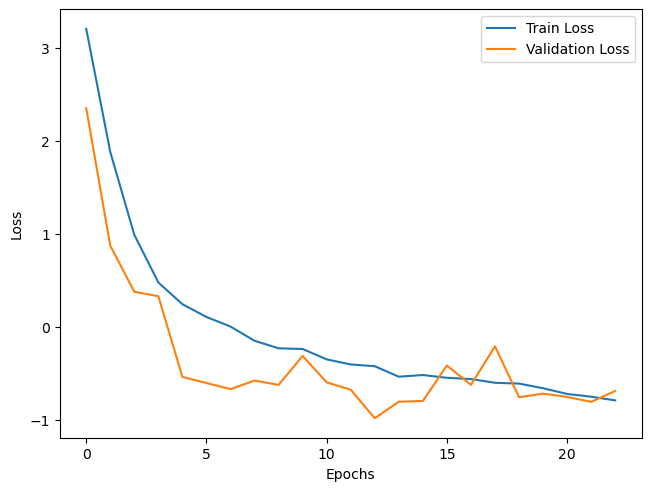

In [23]:
# Plot training/validation loss
dl.plot_losses(train_losses, val_losses, PATH=LOSS_PATH)

### Evaluating the model

In [ ]:
# Compute the test predictions and loss
y_test_pred, test_loss = dl.test_nn(test_loader, model, loss_fn, device)

print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Final Train Loss: -0.7881
Final Validation Loss: -0.6884
Final Test Loss: -1.0881
